# Quickstart

## k nearest neighbour search
To get started, let's create a random uniform distribution and find some neighbours!

In [1]:
import jax
import jax.numpy as jnp
import jztree as jz

# self-query
pos = jax.random.uniform(jax.random.key(0), shape=(int(1e7), 3))

rnn, inn = jz.knn.knn.jit(pos, k=4)

print("Self-query:", rnn.shape, inn.shape)
print(rnn[0])
print(inn[0])

Self-query: (10000000, 4) (10000000, 4)
[0.         0.00211055 0.00308441 0.0039642 ]
[      0 6307584 5332499 2674456]


or with a separate set of query positions:

In [2]:
posq = jax.random.uniform(jax.random.key(1), shape=(int(5e6), 3))

rnn, inn = jz.knn.knn.jit(pos, k=4, part_query=posq)
print("Separate query:", rnn.shape, inn.shape)
print(rnn[0])
print(inn[0])

Separate query: (5000000, 4) (5000000, 4)
[0.00304076 0.00344077 0.00382814 0.00440932]
[1295882 1951754 8741135 4396358]


That's it already! The code has calculated the radii and the indices of the nearest neighbours of every particle.

As usual in **jax**, it is important to just-in-time (jit) compile functions to get good performance. Functions in **jz-tree** never use a @jax.jit decorator, to make it easier to debug them. However, for convenience we have added a .jit attribute that provides a jitted instance. E.g. if you check the **jztree.knn** module, just after the knn function you will find something like this:
```python
knn.jit = jax.jit(knn, static_argnames=("k", "boxsize", "result", "reduce_func", "output_order", "cfg"))
```
Of course you may instead use your own **jax.jit**, for example:

In [3]:
import time

@jax.jit
def myneighbours(seed):
    pos = jax.random.uniform(jax.random.key(0), shape=(int(1e7), 3))
    return jz.knn.knn(pos, k=8)

t0 = time.perf_counter()
rnn, inn = myneighbours(seed=0)
t1 = time.perf_counter()
rnn2, inn2 = myneighbours(seed=1)
t2 = time.perf_counter()

print(f"Dt1 = {t1-t0:.2f}s, Dt2 = {t2-t1:.2f}s")

Dt1 = 2.86s, Dt2 = 0.22s


As usual in jax, the first time we run a jitted function, it will take extra-time to compile. Subsequent executions are much faster! (Timings are from my Laptop with a mobile NVIDIA 4070 GPU.)

Let's verify by comparing to **scipy**'s KDTree (you may need to install it with `pip install scipy`)

In [4]:
from scipy.spatial import KDTree
import numpy as np

pos = jax.random.uniform(jax.random.key(0), shape=(int(1e7), 3))
jz.knn.knn.jit(pos, k=8) # discard compilation for profiling

t0 = time.perf_counter()
rnn, inn = jz.knn.knn.jit(pos, k=8)
t1 = time.perf_counter()
kdtree = KDTree(np.array(pos))
rnn2, inn2 = kdtree.query(pos, k=8, workers=8)
t2 = time.perf_counter()

print("All radii identical", np.allclose(rnn, rnn2))
print("Fraction of indices different:", np.mean(inn != inn2))
print("Radius collision fraction:", np.mean(rnn[:,1:] == rnn[:,:-1]))
print(f"jz-tree: {t1-t0:.2f}s, scipy: {t2-t1:.2f}s")

All radii identical True
Fraction of indices different: 2e-07
Radius collision fraction: 4.4285713e-07
jz-tree: 0.27s, scipy: 19.63s


Quite a speed-up! 

Note that the results agree perfectly within the margin of error: All neighbour radii are exactly identical, but a very small number of indices differ. This is because for $10^7$ particles, we already get a notable number of floating point collisions (where two or more radii in a neighbour list are identical at machine precision). **scipy** and **jz-tree** have a different tie-breaking behaviour. Feel free to verify that for each differing index there is a second particle at the same radius.

## Friends-of-friends

Next, let's find some friends-of-friends clusters. For convenience, the output from a 2D cosmological
N-body simulation (run with [DISCO-DJ](https://github.com/cosmo-sims/DISCO-DJ)) is included in the repository. 
It has $128^2$ particles with a boxsize of 100.

In [5]:
from jztree_utils.ics import cosmo_2d_sample

pos = cosmo_2d_sample()
print(pos.shape)
mean_sep = 100./128

posz, igroup = jz.fof.fof_labels.jit(pos, rlink=0.2*mean_sep, boxsize=100.0)

print(posz.shape, igroup.shape)
print(igroup[0:40])

(16384, 2)
(16384, 2) (16384,)
[ 0  1  2  3  4  5  6  7  6  9 10 11 12 13 14 15 16 16 16 16 20 21 22 23
 24 16 16 27 27 23 30 27 27 33 34 35 35 35 38 39]


Note that **jztree.fof.fof_labels** outputs positions and group labels in z-order. For convience, the
single-GPU version shown here also supports restoring the input ordering (`output_order="input"`). However,
this is not really a feasible option in the multi-GPU scenario where it is best to continue working
with the re-ordered particles.

The igroup labels point towards the first particle that is part of the same group. Many particles 
just point to themselves which means that they are a single-particle group.

Let's visualize this data:

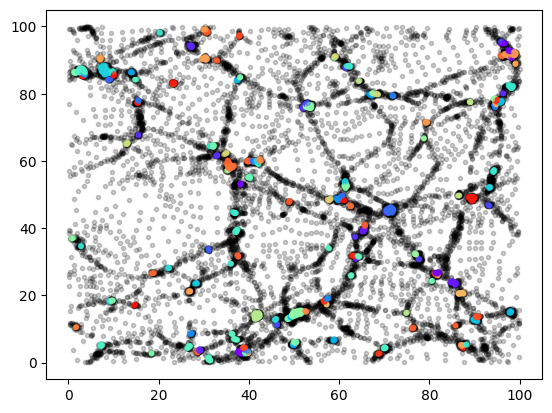

In [6]:
posz, igroup = jz.fof.fof_labels.jit(pos, rlink=0.2*100./128, boxsize=100.)

count = jnp.zeros_like(igroup).at[igroup].add(1)

import matplotlib.pyplot as plt
plt.scatter(posz[:,0], posz[:,1], marker=".", alpha=0.2, color="black")

sel = count[igroup] > 10
color = plt.get_cmap("rainbow")((igroup[sel] % 133) / 133)
plt.scatter(posz[sel,0], posz[sel,1], c=color, marker=".", alpha=0.2);

Here we have drawn only coloured particles that are in a group with more than 10 particles. The
operation
```python
count = jnp.zeros_like(igroup).at[igroup].add(1)
```
counts the particles in each group. We'll see more sophisticated catalogue reductions later.

We may again wish to test our output against another library. Let's setup a larger problem in
three dimensions. (Note: By default, **jz-tree** supports FoF in 2 and 3 dimensions, but if you
need a different dimension, you can easily add it, by recompiling from sources).

Running the following requires installing [hfof](https://github.com/pec27/hfof) -- which is as far
as I know the fastest publicly available single-CPU FoF library:

In [7]:
import hfof

pos = jax.random.uniform(jax.random.key(0), shape=(int(1e7), 3))
mean_sep = np.cbrt(1./len(pos))

jz.fof.fof_labels.jit(pos, rlink=0.7*mean_sep, boxsize=1.0) # discard jit-compilation for profiling

t0 = time.perf_counter()
posz, igroup = jz.fof.fof_labels.jit(pos, rlink=0.7*mean_sep, boxsize=1.0)
t1 = time.perf_counter()
ihfof = hfof.fof(np.array(posz), 0.7*mean_sep, boxsize=1.)
t2 = time.perf_counter()

print("jz-tree:", igroup[0:20])
print("hfof:", ihfof[0:20])
print("labels consistent:", jz.fof.fof_is_superset(igroup, ihfof), jz.fof.fof_is_superset(ihfof, igroup))
print(f"Dt1 = {t1-t0:.2f}s, Dt2 = {t2-t1:.2f}s")

Loading libhfof - C functions for FoF calculations /home/jens/.virtualenvs/uvjax/lib/python3.12/site-packages/hfof/../build/libhfof.cpython-312-x86_64-linux-gnu.so
jz-tree: [ 0  1  0  0  4  5  6  6  8  8  8 11 11  1 14 14 14 17 18 19]
hfof: [  23968     141   23968   23968       0   23846   23847   23847   23969
   23969   23969       1       1     141     142     142     142 4267019
 4267018 4267020]
labels consistent: True True
Dt1 = 0.11s, Dt2 = 4.47s


Again, a significant speed-up -- though the performance of **hfof** is also quite impressive, given the limited hardware used!

Note that the labels differ, but they represent the same groups. This is verified by calling the `jz.fof.fof_is_superset` function in both directions.

## Friends-of-friends catalogues

Usually FoF algorithms are run as a preparation step to create group catalogues that summarize FoF groups. This is also
supported in **jz-tree**. To allow a convenient group-wise access to the particles they are brought into
group order. To simplify visualization, we again use the cosmo 2D dataset:

catalogue num, shape: 164 (1639,)
squeezed catalogue num, shape: 164 (164,)


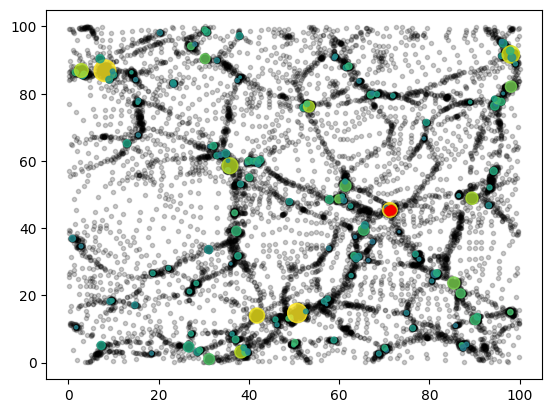

In [8]:
pos = cosmo_2d_sample()

part = jz.data.ParticleData(
    pos = pos,
    mass = 1., # mass may be a constant or an array with number of particles
    vel = jax.random.normal(jax.random.key(0), pos.shape)
)

cfg = jz.config.FofConfig()
cfg.catalogue.npart_min = 10
mean_sep = 100./128
partf, cata = jz.fof.fof_and_catalogue.jit(part, rlink=0.2*mean_sep, boxsize=100., cfg=cfg)

print("catalogue num, shape:", cata.ngroups, cata.mass.shape)

cata = jz.data.squeeze_catalogue(cata)

print("squeezed catalogue num, shape:", cata.ngroups, cata.mass.shape)

plt.scatter(partf.pos[:,0], partf.pos[:,1], marker=".", alpha=0.2, color="black")

color = plt.get_cmap("viridis")(np.log10(cata.mass) / 2.5)
plt.scatter(cata.com_pos[:,0], cata.com_pos[:,1], c = color,
            s=200.*cata.com_inertia_radius**2, marker="o", alpha=0.8)

imax = np.argmax(cata.count)
pmax = partf.pos[cata.offset[imax]: cata.offset[imax]+cata.count[imax]]
plt.scatter(pmax[:,0], pmax[:,1], marker=".", color="red", alpha=0.1);

This example shows a few relevant details:
* To be able to calculate group properties like masses or velocities, we should input a particle data structure with those fields.
* We create and pass a config object to configure the minimal number of particles for groups (default is 20). Many functions in **jz-tree** have such a config interface for defining lower-level details.
* `fof_and_catalogue` returns particles in group-prder and an instance of the dataclass **jztree.data.FofCatalouge**.
* The returned catalogue is larger than the actual number of groups. This is necessary, because the number of groups is *data-dependent*, but allocations need to be known at jit-compile time. **jz-tree** uses a worst-case estimate of the allocation size.
* The function `jz.data.squeeze_catalogue` can be used to squeeze the catalogue. (This cannot be done inside of a jitted context.)
* We plot the haloes centers, with size given by their inertia radius and coloured by their mass. You can find all available fields (here)
* Particles can be accessed per group as a continuous range `cata.offset[gid]: cata.offset[gid]+cata.count[gid]`. Here, we have plotted the particles of the most massive halo in red.

## Error handling

If you are going far enough away from the scenarios that we have tested, you may sometimes
encounter error messages like the following:

In [9]:
import jax
import jztree as jz

pos = jax.random.uniform(jax.random.key(0), shape=(50000, 3))
rnn, inn = jz.knn.knn.jit(pos, k=2000)

ERROR:2026-04-05 00:14:06,135:jax._src.callback:442: jax.io_callback failed
Traceback (most recent call last):
  File "/home/jens/.virtualenvs/uvjax/lib/python3.12/site-packages/jax/_src/callback.py", line 440, in io_callback_impl
    return tree_util.tree_map(np.asarray, callback(*args))
                                          ^^^^^^^^^^^^^^^
  File "/home/jens/.virtualenvs/uvjax/lib/python3.12/site-packages/jax/_src/callback.py", line 70, in __call__
    return tree_util.tree_leaves(self.callback_func(*args, **kwargs))
                                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/jens/repos/jz-tree/src/jztree/jax_ext.py", line 199, in _raise
    raise exc(txt)
RuntimeError: 
======== Relevant Error Message =========
RuntimeError at /home/jens/repos/jz-tree/src/jztree/knn.py:98:
The interaction list allocation is too small. (need: 693225, have: 533760)
Hint: increase alloc_fac_ilist at least by a factor of 1.3
 Trace (last 12, tracing time, most recent call last

JaxRuntimeError: INTERNAL: CpuCallback error calling callback: Traceback (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/home/jens/.virtualenvs/uvjax/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>
  File "/home/jens/.virtualenvs/uvjax/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
  File "/home/jens/.virtualenvs/uvjax/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 739, in start
  File "/home/jens/.virtualenvs/uvjax/lib/python3.12/site-packages/tornado/platform/asyncio.py", line 211, in start
  File "/home/jens/.local/share/uv/python/cpython-3.12.11-linux-x86_64-gnu/lib/python3.12/asyncio/base_events.py", line 645, in run_forever
  File "/home/jens/.local/share/uv/python/cpython-3.12.11-linux-x86_64-gnu/lib/python3.12/asyncio/base_events.py", line 1999, in _run_once
  File "/home/jens/.local/share/uv/python/cpytho

Jax puts a lot of noise into this type of error. (Note: the error is raised from a CPU callback function, so far this
is the only way to abort a jitted computation based on dynamical data in jax... It's not pretty and we can only hope that they improve this...)
The relevant part of the error message says: "The interaction list allocation is too small. (need: 693225, have: 533760). Hint: increase alloc_fac_ilist at least by a factor of 1.3"

This is actually quite understandable. For returning 2000 neighbours a notably larger region needs to be checked than in typical scenarios... therefore, the code needs a larger allocation for the interaction list. As mentioned earlier, jax's jit compilation requires that allocations are predicted in advance. **jz-tree** trys its best to provide robust defaults, but it is of course not possible to anticipate every possible way things may go wrong.

The solution is pretty simple: we simply update our configuration to use a larger allocation and the code runs through fine!

In [11]:
cfg = jz.config.KNNConfig(alloc_fac_ilist=400)
pos = jax.random.uniform(jax.random.key(0), shape=(50000, 3))
rnn, inn = jz.knn.knn.jit(pos, k=2000, cfg=cfg)
print(rnn.shape, inn.shape)

(50000, 2000) (50000, 2000)
